# Geometric Brownian Motion Demo

Larysa Matiukha, Aleksei Sorokin, and Sou-Cheng T. Choi

Illinois Institute of Technology

Modification date: 9/11/2026

Creation date: 8/24/2024

For reproducibility, this notebook was run with:
- Python 3.13.13, NumPy 2.5.0, SciPy 1.17.1, QMCPy 2.4, QuantLib 1.43, Matplotlib 3.10.9, ipywidgets 8.1.7
- Platform: macOS 26.5.2
- Random seeds: 42 (QMCPy, `cf.QMCPY_SEED`), 7 (QuantLib, `cf.QUANTLIB_SEED`)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/GBM/gbm_demo.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  import sys
  import os
  repo_root = "/content/QMCSoftware"
  notebook_dir = f"{repo_root}/demos/GBM"
  if not os.path.isdir(repo_root):
    !git clone -q --depth 1 https://github.com/QMCSoftware/QMCSoftware {repo_root}
  !pip install -q qmcpy
  !pip install -q ipywidgets QuantLib
  os.chdir(notebook_dir)
  if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)
  extra_path = f"{repo_root}/demos/GBM/gbm_code"
  if extra_path not in sys.path:
    sys.path.insert(0, extra_path)


In [2]:
try:
    import qmcpy as qp 
except ModuleNotFoundError:
    !pip install -q qmcpy

In [3]:
import qmcpy as qp
import numpy as np
import scipy.stats as sc
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import os

import latex_util as lu
import plot_util as pu
import data_util as du
import quantlib_util as qlu
import qmcpy_util as qpu
import config as cf
import averaged_mae as am

In [4]:
# Create output directory
os.makedirs('outputs', exist_ok=True)
os.makedirs('images', exist_ok=True)

# Toggle debug mode
cf.is_debug = IN_COLAB  # use the smaller parameter sweep on Colab's limited runtime

Geometric Brownian motion (GBM) is a continuous stochastic process in which the natural logarithm of its values follows a Brownian motion. $[1]$

Mathematically, it can be defined as follows:

$\large{S_t = S_0 \, e^{\big(\mu - \frac{\sigma^2}{2}\big)  t + \sigma W_t}}$, 

where
* $S_0$ is the initial value, 
* $\mu$ is a drift coefficient
* $\sigma$ is the volatility  
* $W_t$ is a (standard) Brownian motion.

GBM is commonly used to model stock prices and options payoffs. 

Note that QMCPy uses the diffusion coefficient $\sigma^2$ as a parameter. 



## GBM Objects in QMCPy

Geometric Brownian Motion in QMCPy inherits from BrownianMotion class $[2, 3]$. 

Let's explore the constructor and sample generation methods through the built-in help documentation:

In [5]:
help(qp.GeometricBrownianMotion.__init__)

Help on function __init__ in module qmcpy.true_measure.geometric_brownian_motion:

__init__(
    self,
    sampler,
    t_final=1,
    initial_value=1,
    drift=0,
    diffusion=1,
    decomp_type='PCA',
    monitoring_times=None,
    lazy_load=True,
    lazy_decomp=True
)
    Args:
        sampler (DiscreteDistribution/TrueMeasure): A discrete distribution or true measure.
        t_final (float): End time for the geometric Brownian motion, non-negative.
        initial_value (float): Positive initial value of the process, $S_0$.
        drift (float): Drift coefficient $\gamma$.
        diffusion (float): Positive diffusion coefficient $\sigma^2$, where $\sigma$ is volatility.
        decomp_type (str): Method of decomposition, either "PCA", "Cholesky", or "BrownianBridge".
        monitoring_times (Union[np.ndarray, list]): Optional custom sampling times for
            `decomp_type='BrownianBridge'`; see `BrownianMotion`. With `decomp_type`
            `'PCA'` or `'Cholesky'`, the

In [6]:
help(qp.GeometricBrownianMotion.gen_samples)

Help on function gen_samples in module qmcpy.true_measure.geometric_brownian_motion:

gen_samples(
    self,
    n=None,
    n_min=None,
    n_max=None,
    return_weights=False,
    warn=True
) -> Union[numpy.ndarray, Tuple[numpy.ndarray, numpy.ndarray]]
    Generate GBM samples using the parent's transform pipeline.

    Args:
        n (int): number of samples to generate
        n_min (int): minimum index of sequence
        n_max (int): maximum index of sequence
        return_weights (bool): whether to return Jacobian weights
        warn (bool): whether to warn about sample generation

    Returns:
        samples (Union[ndarray,tuple]): GBM samples, optionally with weights if return_weights=True



Now let's create a simple GBM instance and generate sample paths to see the class in action:

In [7]:
gbm = qp.GeometricBrownianMotion(qp.Lattice(2, seed=cf.QMCPY_SEED))
gbm

GeometricBrownianMotion (AbstractTrueMeasure)
    time_vec        [0.5 1. ]
    drift           0
    diffusion       1
    mean_gbm        [1. 1.]
    covariance_gbm  [[0.649 0.649]
                     [0.649 1.718]]
    decomp_type     PCA

In [8]:
gbm.gen_samples(n=4)  # print four samples

array([[0.72608046, 0.70071241],
       [0.38739775, 0.07432173],
       [0.81262942, 1.66867239],
       [0.619371  , 0.31898397]])

### Log-Normality Property

At any time $t > 0$, $S_t$ follows a log-normal distribution with expected value and variance as follows (see Section 3.2 in $[1]$):

- $E[S_t] = S_0 e^{\mu t}$
- $\text{Var}[S_t] = S_0^2 e^{2\mu t}(e^{\sigma^2 t} - 1)$

The log-normal property keeps prices strictly positive within the GBM model while allowing unlimited upside, which makes GBM central to Black-Scholes and related models.

Let's validate these theoretical properties by generating a large number of GBM samples and comparing the empirical moments with the theoretical values. Note that the theoretical values match the last values in `qp_gbm.mean_gbm` and `qp_gbm.covariance_gbm` for the final time point.

In [9]:
# Generate GBM samples for theoretical validation
S0, mu, sigma, T, n_samples = 100.0, 0.05, 0.20, 1.0, 2**12
diffusion = sigma**2
sampler = qp.Lattice(5, seed=cf.QMCPY_SEED)
qp_gbm = qp.GeometricBrownianMotion(sampler, t_final=T, initial_value=S0, drift=mu, diffusion=diffusion)
paths = qp_gbm.gen_samples(n_samples)
S_T = paths[:, -1]  # Final values only

# Calculate theoretical vs empirical sample moments
theo_mean = S0 * np.exp(mu * T)
theo_var = S0**2 * np.exp(2*mu*T) * (np.exp(diffusion * T) - 1)
qp_emp_mean = np.mean(S_T)
qp_emp_var = np.var(S_T, ddof=0) 
print(f"Mean: {qp_emp_mean:.3f} (theoretical: {theo_mean:.3f})")
print(f"Variance: {qp_emp_var:.3f} (theoretical: {theo_var:.3f})")
qp_gbm

Mean: 105.127 (theoretical: 105.127)
Variance: 449.666 (theoretical: 451.029)


GeometricBrownianMotion (AbstractTrueMeasure)
    time_vec        [0.2 0.4 0.6 0.8 1. ]
    drift           0.050
    diffusion       0.040
    mean_gbm        [101.005 102.02  103.045 104.081 105.127]
    covariance_gbm  [[ 81.943  82.767  83.599  84.439  85.288]
                     [ 82.767 167.869 169.556 171.26  172.981]
                     [ 83.599 169.556 257.923 260.516 263.134]
                     [ 84.439 171.26  260.516 352.258 355.798]
                     [ 85.288 172.981 263.134 355.798 451.029]]
    decomp_type     PCA

## GMB vs Brownian Motion Comparison

Below we compare Brownian motion and geometric Brownian motion using the same parameters: `drift` = 0, `diffusion` = 1, `initial_value` = 1.


First, let's define a utility function that will help us visualize GBM paths with different samplers and parameters:

In [10]:
def plot_paths(motion_type, sampler, t_final, initial_value, drift, diffusion, n, png_filename=None):
    if motion_type.upper() == 'BM':
        motion = qp.BrownianMotion(sampler, t_final, initial_value, drift, diffusion)
        title = f'Realizations of Brownian Motion using {type(sampler).__name__} points'
        ylabel = '$W(t)$'
    elif motion_type.upper() == 'GBM':
        motion = qp.GeometricBrownianMotion(sampler, t_final, initial_value, drift, diffusion)
        title = f'Realizations of Geometric Brownian Motion using {type(sampler).__name__} points'
        ylabel = '$S(t)$'
    else:
        raise ValueError("motion_type must be 'BM' or 'GBM'")
    
    t = motion.gen_samples(n)
    initial_values = np.full((n, 1), motion.initial_value)
    t_w_init = np.hstack((initial_values, t))
    tvec_w_0 = np.hstack(([0], motion.time_vec))

    plt.figure(figsize=(7, 4));
    _ = plt.plot(tvec_w_0, t_w_init.T); 
    _ = plt.title(title);
    _ = plt.xlabel('$t$');
    _ = plt.ylabel(ylabel);
    _ = plt.xlim([tvec_w_0[0], tvec_w_0[-1]]);
    if png_filename:   # save .png to images/
        os.makedirs('images', exist_ok=True)
        plt.savefig(f'images/{png_filename}.png', bbox_inches='tight');
    plt.show();

# GBM vs Brownian Motion

Paths of the driftless Brownian motion fluctuate symmetrically around the initial value (y = 1) and frequently cross zero into negative territory, while Geometric Brownian Motion paths remain strictly positive throughout their evolution. 

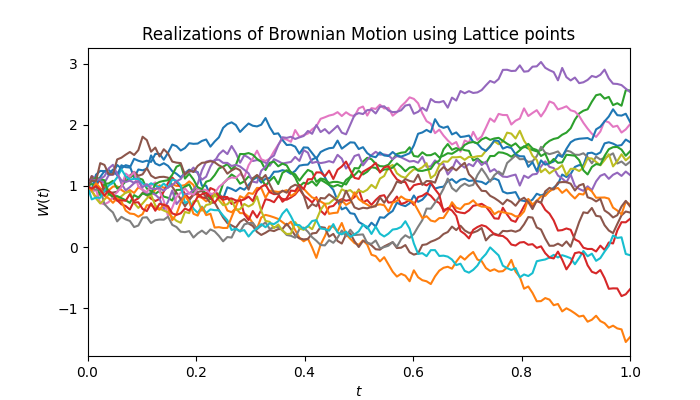

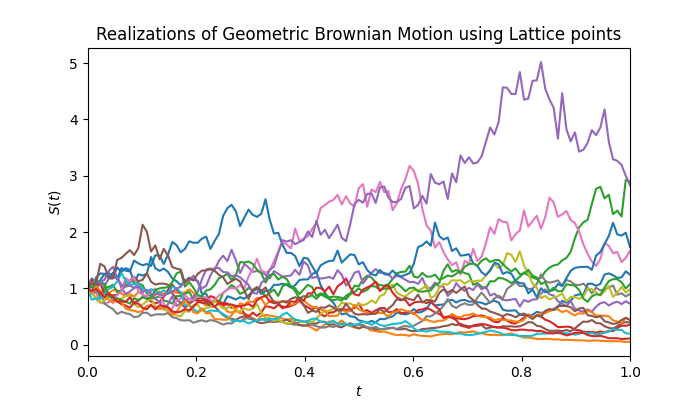

In [11]:
# Compare Brownian Motion and Geometric Brownian Motion using the unified plotting function
n = 16
sampler = qp.Lattice(2**7, seed=cf.QMCPY_SEED)
plot_paths('BM', sampler, t_final=1, initial_value=1, drift=0, diffusion=1, n=n, png_filename='figure_1')
plot_paths('GBM', sampler, t_final=1, initial_value=1, drift=0, diffusion=1, n=n, png_filename='figure_2')

Now, using `plot_gbm_paths`, we generate 32 GBM paths to model stock price, $S(t)$, with initial value $S_0$ = 50, drift coeffient, $\mu = 0.1$, diffusion coefficient $\sigma = 0.2$ using IID points.

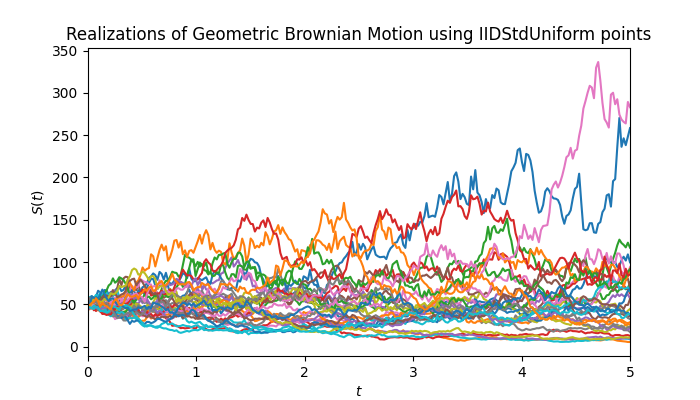

In [12]:
gbm_iid = plot_paths('GBM', qp.IIDStdUniform(2**8, seed=cf.QMCPY_SEED), t_final=5, initial_value=50, drift=0.1, diffusion=0.2, n=32, png_filename='figure_3')

## GBM Using Low-Discrepancy Lattice Sequence Distrubtion 

Using the same parameter values as in example above, we generate 32 GBM paths to model stock price using low-discrepancy lattice points:

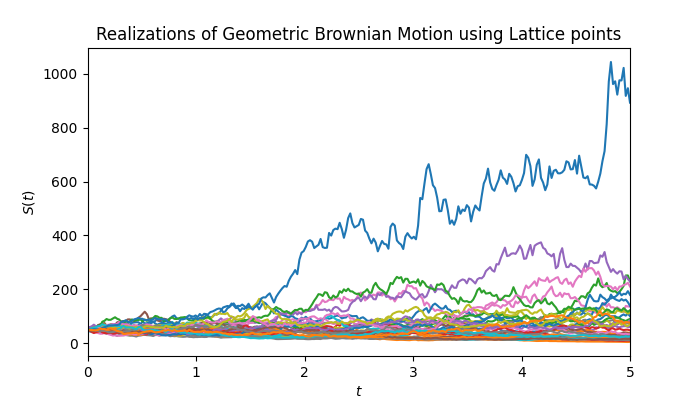

In [13]:
gbm_lattice = plot_paths('GBM', qp.Lattice(2**8, seed=cf.QMCPY_SEED), t_final=5, initial_value=50, drift=0.1, diffusion=0.2, n=32, png_filename='figure_4')

Next, we plot GBM paths and the terminal-value distribution, including its fitted PDF:

In [14]:
def plot_gbm_paths_with_distribution(N, sampler, t_final, initial_value, drift, diffusion,n):
    gbm = qp.GeometricBrownianMotion(sampler, t_final=t_final, initial_value=initial_value, drift=drift, diffusion=diffusion)
    gbm_path = gbm.gen_samples(2**n)
    
    # Handle 3D array (replications, n_paths, n_steps) by taking first replication
    if gbm_path.ndim == 3:
        gbm_path = gbm_path[0]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    T = max(gbm.time_vec)
    
    # Plot GBM paths
    _ = ax.plot(gbm.time_vec, gbm_path.T, lw=0.75, alpha=0.7, color='skyblue')
    
    # Set up main plot
    _ = ax.set_title(f'Geometric Brownian Motion Paths\n{N} Simulations, T = {T}, $\\mu$ = {drift:.1f}, $\\sigma^2$ = {diffusion:.1f}, using {type(sampler).__name__} points')
    _ = ax.set_xlabel(r'$t$')
    _ = ax.set_ylabel(r'$S(t)$')
    _ = ax.set_ylim(bottom=0)
    _ = ax.set_xlim(0, T)
    
    # Add histogram
    final_values = gbm_path[:, -1]
    hist_ax = ax.inset_axes([1.05, 0., 0.5, 1])
    _ = hist_ax.hist(final_values, bins=20, density=True, alpha=0.5, color='skyblue', orientation='horizontal')
    
    # Add theoretical lognormal PDF
    shape, _, scale = sc.lognorm.fit(final_values, floc=0)
    x = np.linspace(0, max(final_values), 1000)
    pdf = sc.lognorm.pdf(x, shape, loc=0, scale=scale)
    _ = hist_ax.plot(pdf, x, 'r-', lw=2, label='Lognormal PDF')
    
    # Finalize histogram
    _ = hist_ax.set_title(f'E[$S_T$] = {np.mean(final_values):.4f}', pad=20)
    _ = hist_ax.axhline(np.mean(final_values), color='blue', linestyle='--', lw=1.5, label=r'$E[S_T]$')
    _ = hist_ax.set_yticks([])
    _ = hist_ax.set_xlabel('Density')
    _ = hist_ax.legend()
    _ = hist_ax.set_ylim(bottom=0)
    fig.tight_layout()
    return fig

## Interactive Visualization

Sliders control the GBM parameters; machine epsilon keeps `initial_value`, `t_final`, and `diffusion` positive. They update when released, replacing one persistent figure display. `plot_gbm_paths_with_distribution` shows paths on the left and the fitted terminal-value PDF on the right.

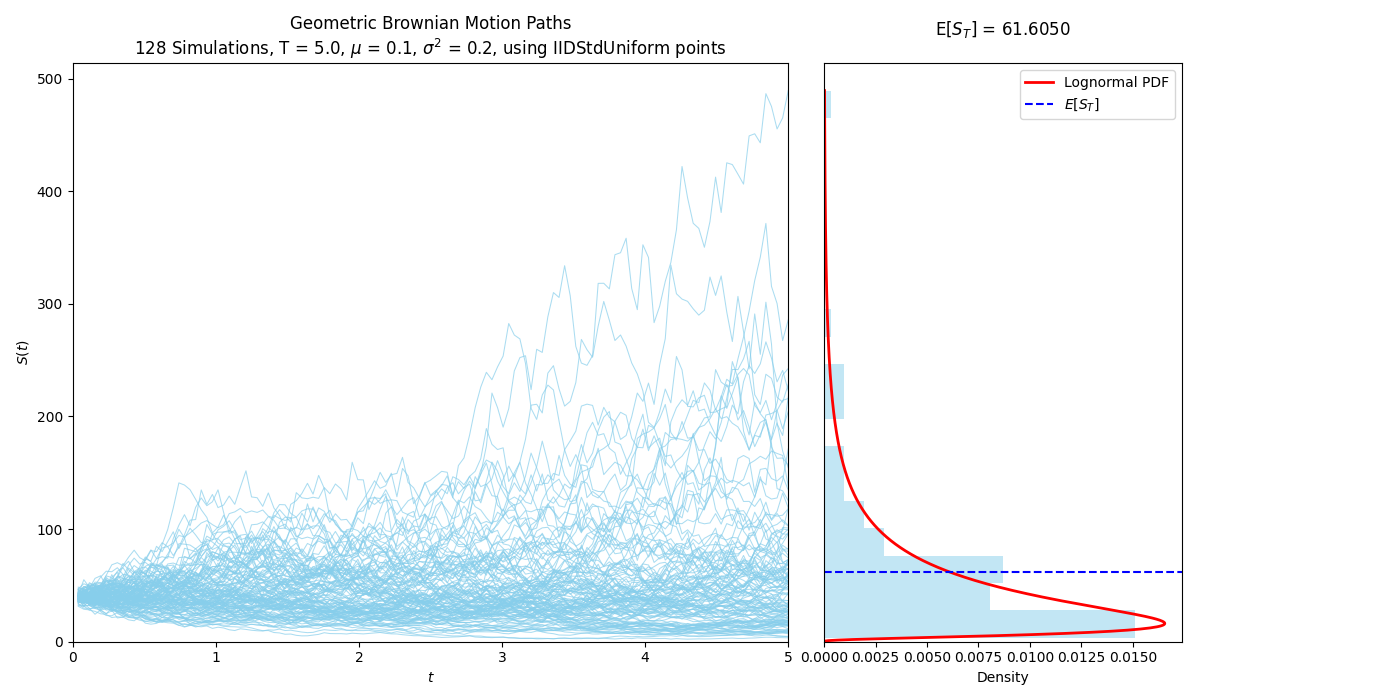

In [15]:
eps = np.finfo(float).eps
slider_style = {'handle_color': 'blue'}
gbm_controls = {
    'n': widgets.IntSlider(description='n', min=0, max=8, step=1, value=7, style=slider_style, continuous_update=False),
    't_final': widgets.FloatSlider(description='t_final', min=eps, max=10, step=0.1, value=5.0, style=slider_style, continuous_update=False),
    'initial_value': widgets.FloatSlider(description='initial_value', min=eps, max=100, step=0.1, value=40, style=slider_style, continuous_update=False),
    'drift': widgets.FloatSlider(description='drift', min=-2, max=2, step=0.1, value=0.1, style=slider_style, continuous_update=False),
    'diffusion': widgets.FloatSlider(description='diffusion', min=eps, max=4, step=0.1, value=0.2, style=slider_style, continuous_update=False),
    'sampler': widgets.Dropdown(description='Sampler', options=['IIDStdUniform', 'Sobol', 'Halton', 'Lattice'], value='IIDStdUniform'),
}
gbm_display = {'handle': None}

def update_gbm_plot(_=None):
    values = {name: control.value for name, control in gbm_controls.items()}
    sampler = qpu.create_qmcpy_sampler(values['sampler'], 2**values['n'])
    fig = plot_gbm_paths_with_distribution(
        2**values['n'], sampler, t_final=values['t_final'],
        initial_value=values['initial_value'], drift=values['drift'],
        diffusion=values['diffusion'], n=values['n'],
    )
    if gbm_display['handle'] is None:
        gbm_display['handle'] = display(fig, display_id=True)
    else:
        gbm_display['handle'].update(fig)
    plt.close(fig)

for control in gbm_controls.values():
    control.observe(update_gbm_plot, names='value')

display(widgets.VBox([*gbm_controls.values()]))
update_gbm_plot()

## QuantLib vs QMCPy Comparison

We compare QMCPy's `GeometricBrownianMotion` with QuantLib [6] for accuracy and runtime.

In [16]:
try:
    import QuantLib as ql
except ModuleNotFoundError:
    !pip install -q QuantLib

### QuantLib Path Generation

The comparison depends on these implementation choices.

**Evolution.** QuantLib's `GeometricBrownianMotionProcess` uses an Euler-Maruyama step $[10]$ and therefore has discretization bias. `BlackScholesMertonProcess` $[6]$ instead applies

$$S_{j+1} = S_j\,\exp\!\big((\mu - \tfrac{\sigma^2}{2})\,\Delta t + \sigma\sqrt{\Delta t}\,Z_j\big).$$

For constant drift and volatility, this is the exact grid-point GBM solution $[4]$, which QMCPy also evaluates. We therefore use `BlackScholesMertonProcess` (`scheme='exact'`, the default); `scheme='euler'` restores the Euler process.

**Samplers.** QuantLib supplies IID, Sobol', and Halton sequences but no lattice rule, so Lattice is QMCPy-only.

* **IID:** QuantLib's `GaussianPathGenerator`, one path per call.
* **Sobol' and Halton:** randomized LD normals followed by the vectorized update above.

Three implementation details matter:

1. **Replications.** The fixed Jaeckel generator does not map different seeds to distinct randomizations. We use `Burley2020SobolRsg` $[8]$, an approximation of Owen scrambling $[9]$, and `HaltonRsg`'s seeded random shift.
2. **Reproducibility.** Jaeckel direction numbers cover 32 dimensions; above that, seed `0` lets QuantLib seed the remainder from the clock. We fix `cf.SOBOL_DIRECTION_SEED` and vary only the scramble seed.
3. **Runtime.** Vectorized formulas match `evolve()` to floating-point tolerance without millions of Python-to-C++ calls.

Points 1 and 2 record behaviour observed in QuantLib 1.38, 1.39, and 1.43, not preferences of ours: both are easy to hit when benchmarking QuantLib directly, and the second is silent, since the paths simply differ between runs. Both are reported upstream, with minimal reproducers: [QuantLib #2731](https://github.com/lballabio/QuantLib/issues/2731) for the seed, [QuantLib #2732](https://github.com/lballabio/QuantLib/issues/2732) for the reproducibility. Re-check both against your own QuantLib version, since either may be resolved upstream.

**Caveats.** QuantLib IID uses its per-path generator, whereas Sobol' and Halton use our vectorized driver, so its IID runtime is not comparable to those rows. That driver is our NumPy code, not QuantLib's, so the Sobol'/Halton QuantLib timings themselves blend QuantLib generation with NumPy evolution -- a runtime ratio against QMCPy for those samplers is therefore not a pure library-vs-library comparison either. The libraries also use different Halton randomizations, so Halton accuracy is not a controlled implementation comparison.

### QMCPy Path Generation

The same three choices, on the QMCPy side.

**Evolution.** `GeometricBrownianMotion` has no time-stepping scheme to choose. It draws a BM at the monitoring times and exponentiates it,

$$S(t) = S_0 \exp\!\big[(\gamma - \tfrac{\sigma^2}{2})\,t + \sigma\,\mathrm{BM}(t)\big],$$

so grid points are exact by construction $[2, 3]$. This is what `scheme='exact'` matches on the QuantLib side, leaving discretization out of the comparison.

**Path construction.** The BM is generated by factoring its covariance matrix $\Sigma = AA^\top$ and applying $A$ to the Gaussian coordinates. `decomp_type` selects the factorization:

* `'PCA'` (the default) takes the eigendecomposition and orders components by decreasing eigenvalue, so the first LD coordinates carry the most variance $[1]$;
* `'Cholesky'` gives the sequential factorization, closest to filling one time step after another, as QuantLib does;
* `'BrownianBridge'` fills the terminal value first, then the midpoint, recursively refining $[1]$.

All three describe the same process and give the same distribution of $S_T$; they differ in how Gaussian coordinates are transformed into the path. Since only the factorization changes, varying `decomp_type` with the sampler held fixed is the controlled ablation that the accuracy results below cannot themselves perform.

**Samplers.** IID, Sobol', Lattice, and Halton, each with its own randomization. The `replications` argument produces independent randomizations of the point set in a single call, which is how the error statistics below are averaged.

For each sampler, we compare the terminal mean and SD with theory over $R$ independent replications of $n$ paths. QMCPy produces all randomized point sets in one call; QuantLib repeats generation with different seeds. For Sobol', those seeds drive independent Burley scrambles $[8, 9]$.

Let $S_T^{(r,i)}$ be terminal value $i$ in replication $r$. The replication mean and SD are

$\bar{S}_r = \frac{1}{n}\sum_{i=1}^{n} S_T^{(r,i)}$,
$\qquad \hat{\sigma}_r = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(S_T^{(r,i)}-\bar{S}_r)^2}$.

Their averages are $\hat{\mu}=R^{-1}\sum_r\bar{S}_r$ and $\hat{\sigma}=R^{-1}\sum_r\hat{\sigma}_r$. With theoretical terminal mean $m$ and SD $s$,

$\text{MAE}= \frac{1}{R}\sum_{r=1}^R |\bar{S}_r-m|$, $\qquad \text{SD error}= \frac{1}{R}\sum_{r=1}^R |\hat{\sigma}_r-s|$.
Within each randomized point set, the denominator is $n$: its points are a dependent quadrature rule, so the IID Bessel correction has no justification. Standard errors use `ddof=1` only across the $R$ independent randomized replications. The table reports each estimate with that replication standard error.

Using $m$ and $s$ avoids confusion with the GBM parameters $\mu$ and $\sigma$.

In [17]:
def compute_theoretical_covariance(S0, mu, sigma, t1, t2):
    """Compute theoretical covariance matrix for GBM at two time points"""
    return np.array([
        [S0**2 * np.exp(2*mu*t1) * (np.exp(sigma**2 * t1) - 1), 
         S0**2 * np.exp(mu*(t1+t2)) * (np.exp(sigma**2 * t1) - 1)],
        [S0**2 * np.exp(mu*(t1+t2)) * (np.exp(sigma**2 * t1) - 1), 
         S0**2 * np.exp(2*mu*t2) * (np.exp(sigma**2 * t2) - 1)]
    ])

def calculate_theoretical_statistics(params):
    """Calculate theoretical mean and SD for GBM."""
    theoretical_mean = params['initial_value'] * np.exp(params['mu'] * params['maturity'])
    theoretical_std = np.sqrt(params['initial_value']**2 * np.exp(2*params['mu']*params['maturity']) * (np.exp(params['sigma']**2 * params['maturity']) - 1))
    return theoretical_mean, theoretical_std


#======= Parameters for GBM comparison
results_data = []
params_ql = {'initial_value': 100, 'mu': 0.05, 'sigma': 0.2, 'maturity': 1.0, 'n_steps': 252, 'n_paths': 2**14, 'seed': cf.QUANTLIB_SEED}
params_qp = {'initial_value': 100, 'mu': 0.05, 'diffusion': 0.2**2, 'maturity': 1.0, 'n_steps': 252, 'n_paths': 2**14, 'replications': 8}
theoretical_mean, theoretical_std = calculate_theoretical_statistics(params_ql)

# Add theoretical values once
du.add_theoretical_results(results_data, theoretical_mean, theoretical_std)
target_times = (params_ql['maturity'] / 2, params_ql['maturity'])
theoretical_cov = compute_theoretical_covariance(params_ql['initial_value'], params_ql['mu'], params_ql['sigma'], *target_times)
print("COMPARISON: QuantLib vs QMCPy GeometricBrownianMotion")
print("="*55)
print(f"\nTheoretical covariance matrix:\n{theoretical_cov}\n")
print(f"{'Theoretical':<12} Mean: {theoretical_mean:.2f}, Theoretical SD: {theoretical_std:.2f}")
# Process each sampler
for sampler_type in ['IIDStdUniform', 'Sobol', 'Halton', 'Lattice']:
    print(f"\n\n{sampler_type = }")
    print("~"*30)
    quantlib_paths, qmcpy_paths, ql_gbm, qp_gbm, params_ql, params_qp = du.process_sampler_data(sampler_type, results_data, theoretical_mean, theoretical_std, params_ql, params_qp)

    # Compute covariance matrices
    if sampler_type in cf.get_sampler_configurations()['quantlib_samplers']:
        ql_time_grid = np.linspace(0, params_ql['maturity'], params_ql['n_steps'] + 1)
        quantlib_cov, _ = du.extract_covariance_samples(quantlib_paths, ql_time_grid, target_times)
        
    qmcpy_cov, _ = du.extract_covariance_samples(qmcpy_paths, qp_gbm.time_vec, target_times)

    # Final value statistics
    if quantlib_paths is not None:
        quantlib_final = quantlib_paths[..., -1]

    #qmcpy_final = qmcpy_paths[:, -1]
    if qmcpy_paths.ndim == 3:
        qmcpy_final = qmcpy_paths[:, :, -1]  # (R, n_paths)
        qmcpy_means = qmcpy_final.mean(axis=1)
    else:
        qmcpy_means = np.array([qmcpy_paths[:, -1].mean()])


    theoretical_mean = params_ql['initial_value'] * np.exp(params_ql['mu'] * params_ql['maturity'])
    theoretical_std = np.sqrt(params_ql['initial_value']**2 * np.exp(2*params_ql['mu']*params_ql['maturity']) * 
                            (np.exp(params_ql['sigma']**2 * params_ql['maturity']) - 1))

    if quantlib_paths is not None: print(f"\nQuantLib sample covariance matrix:\n{quantlib_cov}")
    print(f"\nQMCPy sample covariance matrix:\n{qmcpy_cov}")

    print("\nFINAL VALUE STATISTICS (t=1 year)")
    print("-"*35)
   
    for name, final_vals in [("QuantLib", quantlib_final), ("QMCPy", qmcpy_final)]:
        if name == "QuantLib" and quantlib_paths is None:
            continue
        print(f"{name:<12} Mean: {np.mean(final_vals):.2f}, Empirical SD: {final_vals.std(axis=-1, ddof=0).mean():.2f}")

# Create DataFrame
results_df = pd.DataFrame(results_data)
results_df.round(4)

# Store scalar parameters for the visualization cell
initial_value = params_ql['initial_value']
mu = params_ql['mu']
sigma = params_ql['sigma']
maturity = params_ql['maturity']
n_steps = params_ql['n_steps']
del quantlib_paths, qmcpy_paths, quantlib_final, qmcpy_final, ql_gbm, qp_gbm

COMPARISON: QuantLib vs QMCPy GeometricBrownianMotion

Theoretical covariance matrix:
[[212.37084878 217.74704241]
 [217.74704241 451.02880782]]

Theoretical  Mean: 105.13, Theoretical SD: 21.24


sampler_type = 'IIDStdUniform'
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

QuantLib sample covariance matrix:
[[212.58797015 217.3880459 ]
 [217.3880459  450.28750002]]

QMCPy sample covariance matrix:
[[211.99779115 217.27503369]
 [217.27503369 449.85262133]]

FINAL VALUE STATISTICS (t=1 year)
-----------------------------------
QuantLib     Mean: 105.09, Empirical SD: 21.22
QMCPy        Mean: 105.01, Empirical SD: 21.21


sampler_type = 'Sobol'
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

QuantLib sample covariance matrix:
[[212.13688093 217.91618673]
 [217.91618673 450.90829188]]

QMCPy sample covariance matrix:
[[212.33808601 217.72517238]
 [217.72517238 450.98468371]]

FINAL VALUE STATISTICS (t=1 year)
-----------------------------------
QuantLib     Mean: 105.13, Empirical SD: 21.23
QMCPy        Mean: 105.13, E

In [18]:
results_df.rename(columns={'Std Dev': 'SD', 'Mean Absolute Error': 'MAE', 'Std Dev Error': 'SD Error'})

,Method,Sampler,Mean,SD,MAE,SD Error,Mean SE,Std Dev SE,MAE SE,Std Dev Error SE
0,Theoretical,-,105.127110,21.237439,0.000000,0.000000,NaN,NaN,NaN,NaN
1,QuantLib,IIDStdUniform,105.087830,21.219440,0.141499,0.128662,0.062522,0.057180,0.035624,0.030838
2,QMCPy,IIDStdUniform,105.013212,21.209537,0.152242,0.084997,0.059886,0.034127,0.046136,0.015614
3,QuantLib,Sobol,105.128424,21.234461,0.009692,0.065756,0.004572,0.029146,0.002780,0.015266
4,QMCPy,Sobol,105.126818,21.236400,0.000547,0.002687,0.000193,0.001013,0.000082,0.000387
5,QuantLib,Halton,105.211562,21.500806,0.136223,0.807287,0.059988,0.350032,0.044345,0.198317
6,QMCPy,Halton,105.127332,21.238901,0.000845,0.004075,0.000432,0.001651,0.000303,0.000812
7,QMCPy,Lattice,105.123816,21.223512,0.005264,0.018975,0.001821,0.006707,0.000952,0.004611


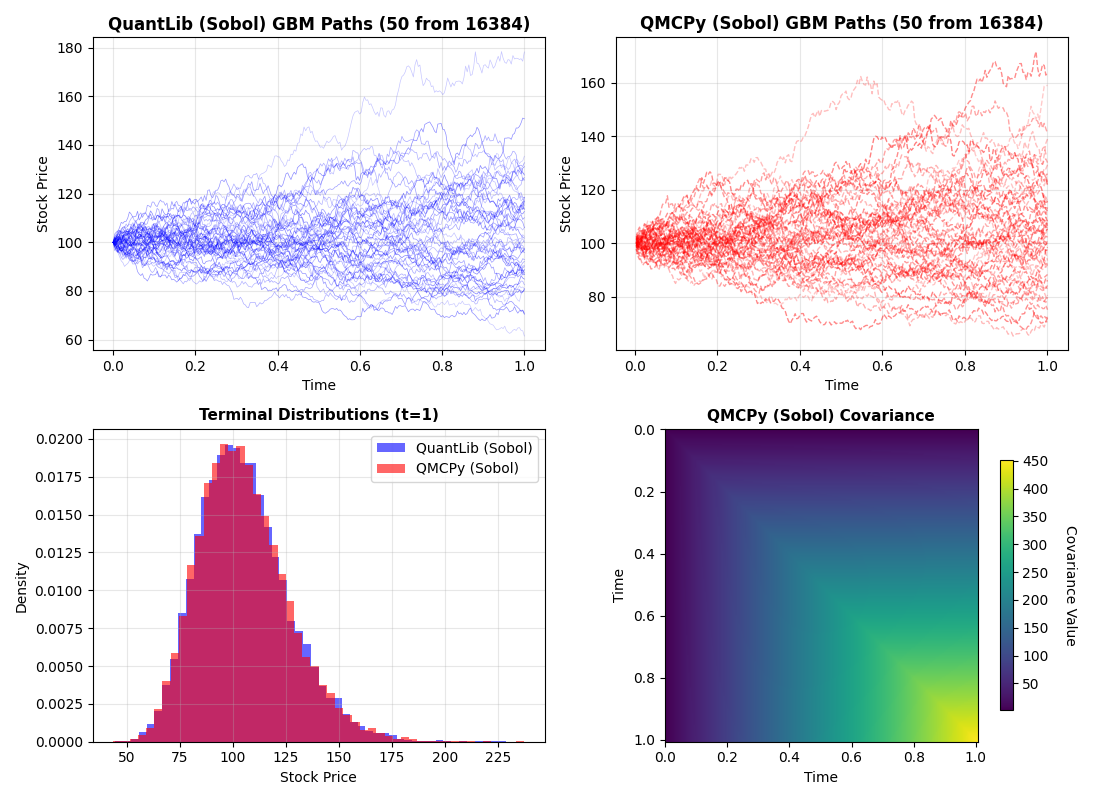

In [19]:
# Visualization 
n_plot=50   # Number of paths to plot
def plot_paths_on_axis(ax, time_vec, paths_data, title, color, linestyle='-', linewidth=0.5, n_plot=50):
    """Helper function to plot GBM paths on a given axis"""
    if paths_data is not None:
        # Handle 3D array (replications, n_paths, n_steps) by squeezing first dimension
        if paths_data.ndim == 3:
            paths_data = paths_data[0]  # Take first replication
        for i in range(min(n_plot, paths_data.shape[0])):
            ax.plot(time_vec, paths_data[i, :], alpha=0.2 + 0.3 * (i / n_plot), color=color, linestyle=linestyle, linewidth=linewidth)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Stock Price')
    ax.grid(True, alpha=0.3)

# Create comparison visualization with 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 8))
sampler_type = "Sobol"
ql_sampler = sampler_type  
qp_sampler = sampler_type  

# Generate specific data for visualization (ensure we have data for both libraries)
params_vis_ql = {'initial_value': 100, 'mu': 0.05, 'sigma': 0.2, 'maturity': 1.0, 'n_steps': 252, 'n_paths': 2**14, 'sampler_type': 'Sobol'}
params_vis_qp = {'initial_value': 100, 'mu': 0.05, 'diffusion': 0.2**2, 'maturity': 1.0, 'n_steps': 252, 'n_paths': 2**14, 'sampler_type': 'Sobol'}

# Generate paths for visualization
vis_quantlib_paths, _ = qlu.generate_quantlib_paths(**params_vis_ql)
vis_qmcpy_paths, vis_qp_gbm = qpu.generate_qmcpy_paths(**params_vis_qp)

# Handle 3D array for QMCPy paths (replications, n_paths, n_steps)
if vis_qmcpy_paths.ndim == 3:
    vis_qmcpy_paths = vis_qmcpy_paths[0]  # Take first replication

vis_quantlib_final = vis_quantlib_paths[:, -1]
vis_qmcpy_final = vis_qmcpy_paths[:, -1]

# Get number of samples for titles
n_samples = vis_quantlib_paths.shape[0] if vis_quantlib_paths is not None else vis_qmcpy_paths.shape[0]

# Create time grids that match path dimensions:
# QuantLib: includes t=0, so n_steps + 1 points
# QMCPy: excludes t=0, so n_steps points (use vis_qp_gbm.time_vec directly)
ql_time_grid = np.linspace(0, maturity, n_steps + 1)
qp_time_grid = vis_qp_gbm.time_vec  # This matches QMCPy path dimensions

plot_data = [ (ax1, ql_time_grid, vis_quantlib_paths, f'QuantLib ({ql_sampler}) GBM Paths ({n_plot} from {n_samples})', 'blue', '-', 0.5),
              (ax2, qp_time_grid, vis_qmcpy_paths, f'QMCPy ({qp_sampler}) GBM Paths ({n_plot} from {n_samples})', 'red', '--', 1.0) ]
for ax, time_grid, data, title, color, linestyle, linewidth in plot_data:
    plot_paths_on_axis(ax, time_grid, data, title, color, linestyle, linewidth)

# Final value distributions
for final_vals, color, label, sampler in [(vis_quantlib_final, 'blue', 'QuantLib', ql_sampler), (vis_qmcpy_final, 'red', 'QMCPy', qp_sampler)]:
    if final_vals is not None:
        ax3.hist(final_vals, bins=50, alpha=0.6, color=color, label=f'{label} ({sampler})', density=True)
ax3.set_title('Terminal Distributions (t=1)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Stock Price')
ax3.set_ylabel('Density')
ax3.legend()
ax3.grid(True, alpha=0.3)

# QMCPy covariance matrix heatmap
im = ax4.imshow(vis_qp_gbm.covariance_gbm, cmap='viridis', aspect='equal') # origin='lower'
ax4.set_title(f'QMCPy ({qp_sampler}) Covariance', fontsize=11, fontweight='bold')
ax4.set_xlabel('Time')
ax4.set_ylabel('Time')

# Set custom tick labels using time_vec
time_ticks = np.arange(0, len(vis_qp_gbm.time_vec), max(1, len(vis_qp_gbm.time_vec)//5))  # Show ~5 ticks
ax4.set_xticks(time_ticks)
ax4.set_yticks(time_ticks)
ax4.set_xticklabels([f'{vis_qp_gbm.time_vec[i]:.1f}' for i in time_ticks])
ax4.set_yticklabels([f'{vis_qp_gbm.time_vec[i]:.1f}' for i in time_ticks])
cbar = plt.colorbar(im, ax=ax4, shrink=0.8)   # Add colorbar
cbar.set_label('Covariance Value', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('images/figure_5.png', bbox_inches='tight')
plt.show();
del vis_quantlib_paths, vis_qmcpy_paths, vis_quantlib_final, vis_qmcpy_final, vis_qp_gbm, plot_data, data, final_vals

We benchmark path generation with `%timeit`, including warm-up and repeated runs.

QMCPy Halton is slowest here because its work scales with an $(n,d,t)$ array of base-$b$ digits. We use `t = cf.HALTON_DIGITS` ($32$ rather than $63$) with the default linear-matrix scramble (LMS) and digital permutation (DP), `'LMS DP'`.

Note that `%timeit` reports timing statistics, not statistical replications: each timed call generates a single replication of the paths, whereas the error panels average over independent randomizations. The runtime panel therefore measures roughly a third of the QMCPy work behind the accuracy panels, and its title states the timing provenance rather than a replication count.

In [20]:
def benchmark_quantlib_samplers(samplers_to_test, base_params):
    """Benchmark QuantLib with different samplers"""
    timing_results = {}
    for sampler_type in samplers_to_test:
        print(f"QuantLib ({sampler_type}) timing:")
        benchmark_func = lambda st=sampler_type: qlu.generate_quantlib_paths(**base_params, sampler_type=st)
        timing_result = %timeit -n 10 -r 3 -o benchmark_func()
        timing_results[sampler_type] = {
            'average': timing_result.average,
            'stdev': timing_result.stdev,
            'loops': timing_result.loops,
            'repeat': timing_result.repeat
        }
    return timing_results

def benchmark_qmcpy_samplers(samplers_to_test, base_params):
    """Benchmark QMCPy samplers with timing measurements"""
    timing_results = {}
    
    # Convert QuantLib parameters to QMCPy parameters if needed
    qp_params = base_params.copy()
    if 'sigma' in qp_params:
        qp_params['diffusion'] = qp_params.pop('sigma') ** 2  # Convert sigma to diffusion (sigma²)
    
    for sampler_type in samplers_to_test:
        print(f"QMCPy ({sampler_type}) timing:")
        benchmark_func = lambda st=sampler_type: qpu.generate_qmcpy_paths(**qp_params, sampler_type=st)
        timing_result = %timeit -n 10 -r 3 -o benchmark_func()
        timing_results[sampler_type] = {
            'average': timing_result.average,
            'stdev': timing_result.stdev,
            'loops': timing_result.loops,
            'repeat': timing_result.repeat
        }
    return timing_results

In [21]:
# Benchmark QuantLib and QMCPy with different samplers
quantlib_samplers_to_benchmark = ['IIDStdUniform', 'Sobol', 'Halton']
qmcpy_samplers_to_benchmark = ['IIDStdUniform', 'Sobol', 'Halton', 'Lattice']
# Create base params without sampler_type to avoid conflicts  
base_ql_params = {k: v for k, v in params_ql.items() if k != 'sampler_type'}
# Add the required parameters for QMCPy benchmarking
base_ql_params.update({'n_steps': 252, 'n_paths': 2**14})
# Create QMCPy parameters (note: diffusion instead of sigma)
base_qp_params = {
    'initial_value': 100, 
    'mu': 0.05, 
    'diffusion': 0.2**2,  # sigma^2 for QMCPy
    'maturity': 1.0, 
    'n_steps': 252, 
    'n_paths': 2**14
}
# Run benchmarks
quantlib_timing_results = benchmark_quantlib_samplers(quantlib_samplers_to_benchmark, base_ql_params)
qmcpy_timing_results = benchmark_qmcpy_samplers(qmcpy_samplers_to_benchmark, base_qp_params)
# Create comprehensive timing table
timing_df = du.create_timing_dataframe(quantlib_timing_results, qmcpy_timing_results)
timing_df.rename(columns={'Std Dev (s)': 'Time SD (s)'}).round(10)

QuantLib (IIDStdUniform) timing:
1.49 s ± 5.24 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)
QuantLib (Sobol) timing:
172 ms ± 905 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)
QuantLib (Halton) timing:
161 ms ± 1.6 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)
QMCPy (IIDStdUniform) timing:
57.4 ms ± 1.11 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)
QMCPy (Sobol) timing:
53.2 ms ± 580 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)
QMCPy (Halton) timing:
793 ms ± 2.73 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)
QMCPy (Lattice) timing:
52.4 ms ± 1.15 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


,Method,Sampler,Mean Time (s),Time SD (s),Speedup (same sampler)
0,QuantLib,IIDStdUniform,1.485403,0.005237,-
1,QuantLib,Sobol,0.171854,0.000905,-
2,QuantLib,Halton,0.160796,0.001598,-
3,QMCPy,IIDStdUniform,0.057387,0.001111,25.883909
4,QMCPy,Sobol,0.053227,0.000580,3.228701
5,QMCPy,Halton,0.793324,0.002731,0.202687
6,QMCPy,Lattice,0.052390,0.001150,-


In [22]:
# Output results to LaTeX
results_df = pd.merge(results_df, timing_df, on=['Method', 'Sampler'])
# Format the results dataframe
numeric_cols = ['Mean', 'Std Dev', 'Mean Absolute Error', 'Std Dev Error', 'Mean Time (s)', 'Std Dev (s)', du.SPEEDUP_COLUMN]
uncertainty_cols = {'Mean': 'Mean SE', 'Std Dev': 'Std Dev SE', 'Mean Absolute Error': 'MAE SE', 'Std Dev Error': 'Std Dev Error SE'}
results_formatted = lu.format_results_dataframe(results_df, numeric_cols, uncertainty_cols)
# Generate and save LaTeX table
title = f"GBM Terminal Statistics ($R={params_qp['replications']}$, $n={params_qp['n_paths']:,}$) and Runtime"
latex_table = lu.generate_latex_table(results_formatted, title, "tab2")
with open('outputs/gbm_comparison_table.tex', 'w') as f:
    _ = f.write(latex_table)

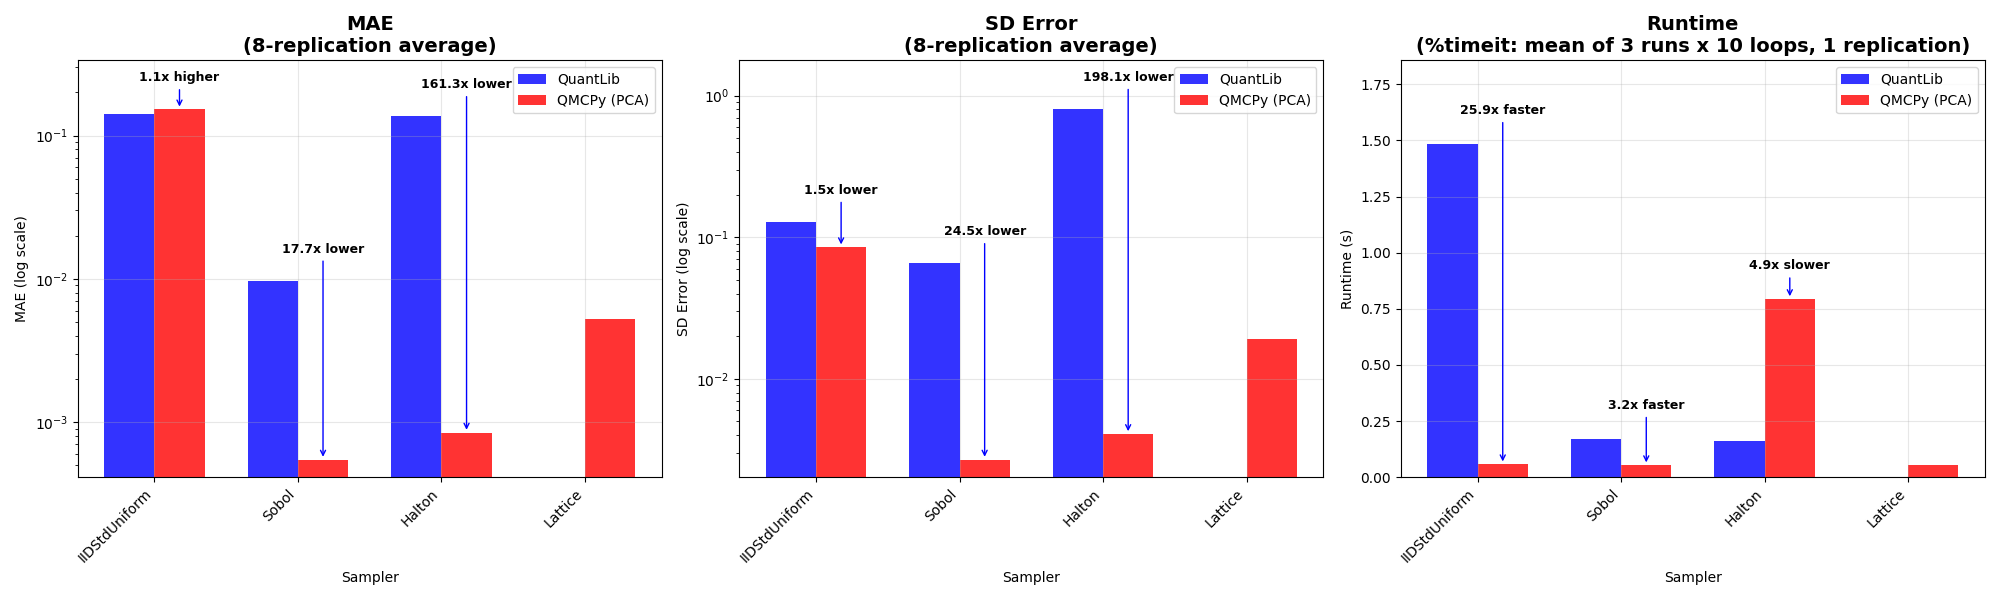

In [23]:
# Three-panel comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
# Extract data for plotting
(samplers, qmcpy_errors, qmcpy_times, quantlib_errors, quantlib_times,
 theoretical_mean, qmcpy_sd_errors, quantlib_sd_errors) = du.extract_comparison_data(results_df)
# MAE, SD error, then runtime
pu.plot_error_comparison(ax1, samplers, qmcpy_errors, quantlib_errors, replications=params_qp['replications'])
pu.plot_error_comparison(ax2, samplers, qmcpy_sd_errors, quantlib_sd_errors, replications=params_qp['replications'], metric='SD Error')
pu.plot_performance_comparison(ax3, samplers, qmcpy_times, quantlib_times,
                               timing_repeat=qmcpy_timing_results['Sobol']['repeat'],
                               timing_loops=qmcpy_timing_results['Sobol']['loops'])
plt.tight_layout()
plt.savefig('images/figure_6.png', bbox_inches='tight', dpi=150)
plt.show();

We sweep `n_steps` and `n_paths`. Rows show the swept parameter; columns show MAE, SD error, and runtime. SD error has its own column because it is a different metric—not uncertainty attached to MAE.

Both errors average eight independent randomizations. This especially stabilizes SD error, which depends on squared deviations and is sensitive to large terminal values. Curves need not be monotone: randomized absolute errors can rise locally, and changing `n_steps` changes the sampling dimension and path construction even with the exact scheme. Lines connect observations without smoothing; `%timeit` measures runtime separately.

In [24]:
%%capture
# MAIN EXPERIMENT RUNNER
replications = 8

def run_single_configuration(series_name, n_steps, n_paths):
    """Run benchmarking for a single parameter configuration"""
    print(f"\nTesting n_steps = {n_steps}, n_paths = {n_paths}")
    
    # Calculate theoretical values
    gbm_params = cf.get_gbm_parameters()
    theoretical_mean, theoretical_std = calculate_theoretical_statistics(gbm_params)
    
    # Prepare benchmark parameters for QuantLib (with sigma)
    ql_params = {**gbm_params, 'n_steps': n_steps, 'n_paths': n_paths}
    
    # Prepare benchmark parameters for QMCPy (with diffusion instead of sigma)
    qp_params = {
        'initial_value': gbm_params['initial_value'],
        'mu': gbm_params['mu'],
        'diffusion': gbm_params['sigma']**2,  # Convert sigma to diffusion
        'maturity': gbm_params['maturity'],
        'n_steps': n_steps,
        'n_paths': n_paths
    }
    
    # Run benchmarks
    samplers = cf.get_sampler_configurations()
    print("  Benchmarking QuantLib...")
    ql_timing = benchmark_quantlib_samplers(samplers['quantlib_samplers'], ql_params)
    
    print("  Benchmarking QMCPy...")
    qp_timing = benchmark_qmcpy_samplers(samplers['all_samplers'], qp_params)
    
    # Collect results for all samplers
    results = []
    du.add_theoretical_row(results, series_name, n_steps, n_paths, theoretical_mean, theoretical_std)
    
    for sampler in samplers['all_samplers']:
        print(f"    Processing {sampler}...")
        sampler_results = du.collect_library_results(
            sampler, series_name, n_steps, n_paths,
            ql_timing, qp_timing, theoretical_mean, theoretical_std, replications
        )
        results.extend(sampler_results)
    
    return results

def run_time_steps_series():
    """Run experiments varying time steps with fixed paths"""
    config = cf.get_experiment_configurations()['time_steps']
    print(f"\nSERIES 1: Varying Time Steps (n_paths fixed at {config['fixed_paths']})")
    print("-" * 60)
    
    all_results = []
    for n_steps in config['range']:
        results = run_single_configuration(
            config['series_name'], n_steps, config['fixed_paths']
        )
        all_results.extend(results)
    
    return all_results

def run_paths_series():
    """Run experiments varying paths with fixed time steps"""
    config = cf.get_experiment_configurations()['paths']
    print(f"\nSERIES 2: Varying Number of Paths (n_steps fixed at {config['fixed_steps']})")
    print("-" * 60)
    
    all_results = []
    for n_paths in config['range']:
        results = run_single_configuration(
            config['series_name'], config['fixed_steps'], n_paths
        )
        all_results.extend(results)
    
    return all_results

def run_comprehensive_parameter_sweep():
    """
    Run comprehensive parameter sweep experiments:
    1. Vary time steps with fixed paths
    2. Vary paths with fixed time steps
    """
    all_results = []
    all_results.extend(run_time_steps_series())
    all_results.extend(run_paths_series())
    
    return pd.DataFrame(all_results)

# MAIN EXECUTION

# Run the comprehensive parameter sweep
sweep_results_df = run_comprehensive_parameter_sweep()

# Save results for later analysis
sweep_results_df.to_csv('outputs/parameter_sweep_results.csv', index=False)

# Display sample of results
print("\nSample of results:")
sample_results = sweep_results_df[sweep_results_df['Method'] != 'Theoretical'].head(10)
print(sample_results[['Series', 'n_steps', 'n_paths', 'Method', 'Sampler', 'Runtime (s)', 'Mean Absolute Error']].round(10))


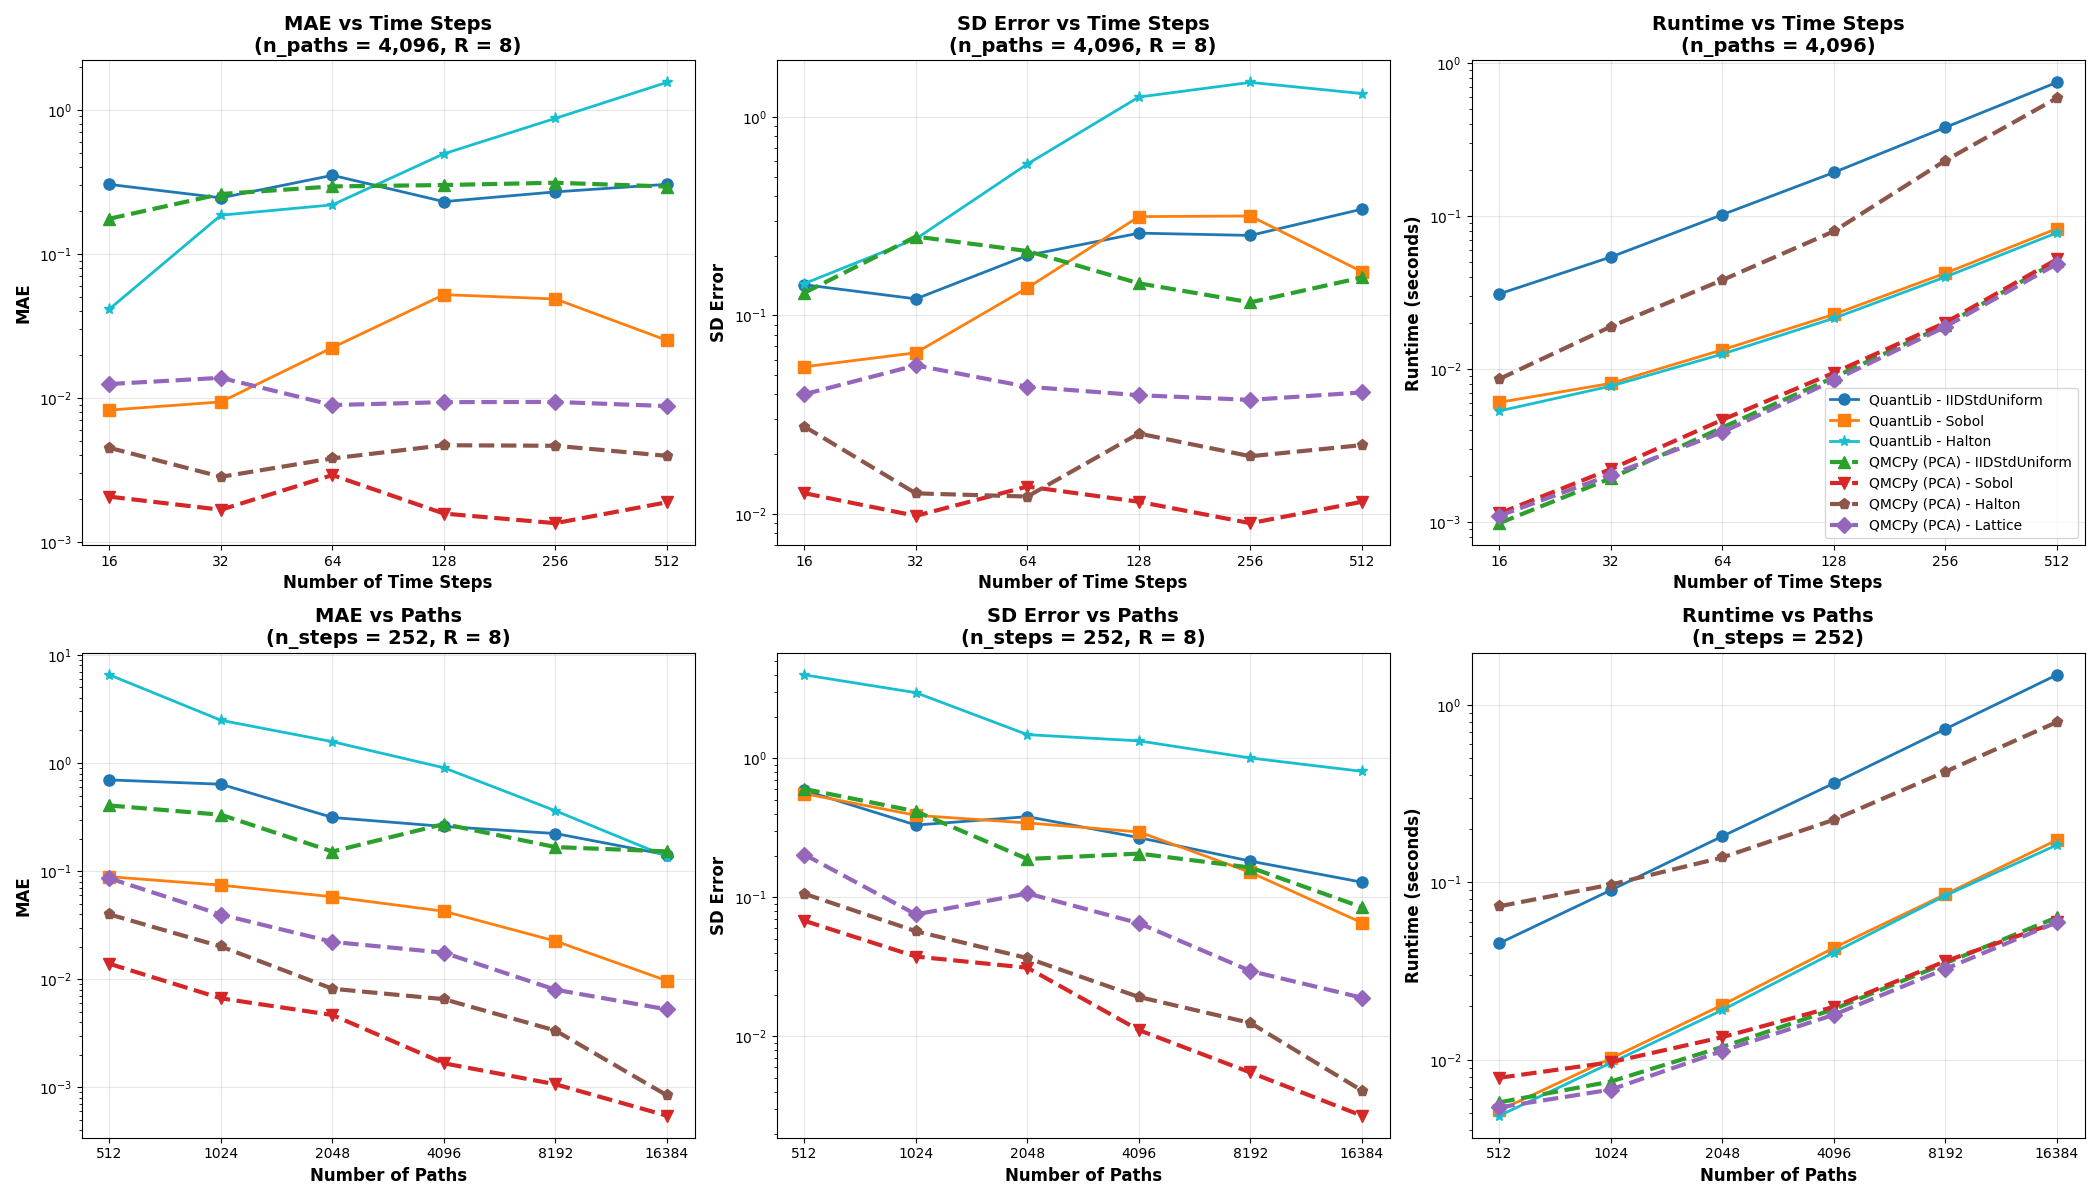

In [25]:
pu.create_parameter_sweep_plots(sweep_results_df, replications)
plt.tight_layout()
plt.savefig('images/figure_7.png', bbox_inches='tight', dpi=150)
plt.show()

## Isolating the Path Construction

The comparison so far changes the point set, its randomization, and the path construction all at once, so it cannot say which of them drives the accuracy differences. Here we hold everything fixed except one factor.

Every run below uses the same sampler, seed, path count, and time grid; only `decomp_type` changes. Any difference in error is therefore attributable to the construction alone.

`IIDStdUniform` acts as the control. A construction redistributes variance across the sampling coordinates, which can help only when those coordinates are equidistributed. IID points are not, so IID accuracy should be roughly flat across constructions while the LD samplers should not be.

/Users/terrya/Documents/ProgramData/QMCSoftware_local/qmcpy/true_measure/geometric_brownian_motion.py:76: ParameterWarning: BrownianBridge is most efficient when d is a power of 2 (e.g., 1, 2, 4, 8, 16). Got d=252.
  super().__init__(


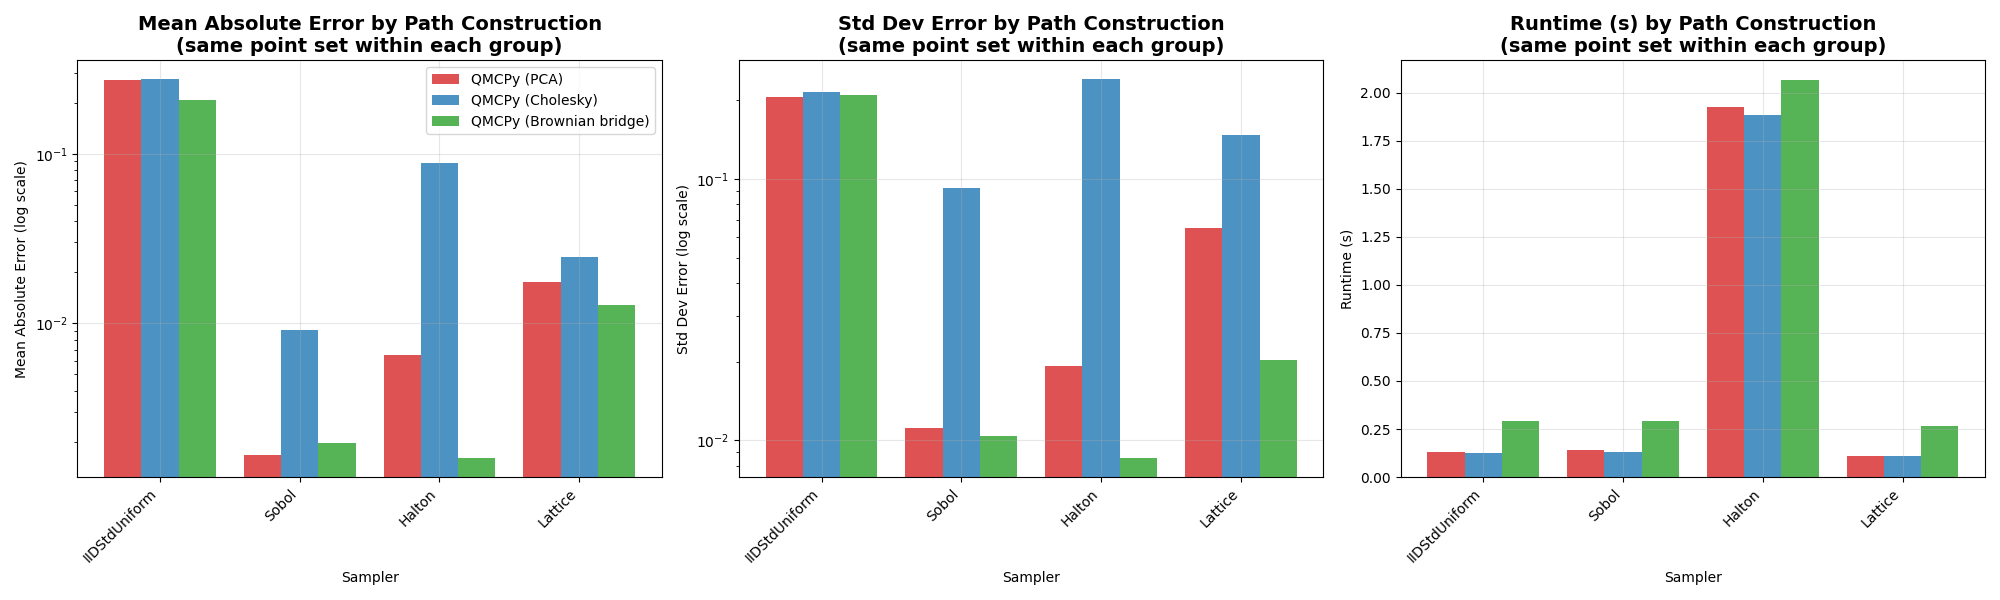

In [26]:
# One factor varies: the path construction
ablation_df = du.run_construction_ablation(
    sampler_types=cf.get_sampler_configurations()['all_samplers'],
    decomp_types=['PCA', 'Cholesky', 'BrownianBridge'],
    theoretical_mean=theoretical_mean,
    theoretical_std=theoretical_std,
    n_paths=2**12,
    n_steps=252,
    replications=replications,
)
# MAE by sampler and construction, with PCA as the reference
mae_table = ablation_df.pivot(index='Sampler', columns='Construction', values='Mean Absolute Error')
mae_table = mae_table[['PCA', 'Cholesky', 'BrownianBridge']].reindex(cf.get_sampler_configurations()['all_samplers'])
mae_table['Cholesky / PCA'] = mae_table['Cholesky'] / mae_table['PCA']
mae_table

# Same point set within each group; only the construction changes
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
pu.plot_construction_ablation(ax1, ablation_df, metric='Mean Absolute Error')
pu.plot_construction_ablation(ax2, ablation_df, metric='Std Dev Error', legend=False)
pu.plot_construction_ablation(ax3, ablation_df, metric='Runtime (s)', legend=False)
plt.tight_layout()
plt.savefig('images/figure_8.png', bbox_inches='tight', dpi=150)
plt.show();

## Conclusions

Both libraries reproduce the theoretical mean and SD of $S_T$ $[1, 4]$; the remaining differences concern path construction.

### Accuracy

* Both libraries evaluate the **exact** GBM solution, so the `n_steps` sweep changes sampling dimension and path construction—not discretization bias. Two things still differ:
    * **Point set and randomization.** QMCPy uses scrambled LD sequences $[9]$. QuantLib uses Jaeckel direction numbers $[7]$ with Burley's scramble $[8]$ for Sobol', and a seeded random shift for Halton.
    * **Path construction.** QMCPy's PCA construction puts most variance in the best-equidistributed dimensions $[1]$; QuantLib fills time steps sequentially, which is closest to QMCPy's `'Cholesky'`.
* QuantLib's Python bindings expose no lattice rule.
* QMCPy's Halton is more accurate in this experiment, but that comparison changes both randomization and path construction, so on its own it cannot attribute the gap to either.
* Holding the point set fixed and varying only `decomp_type` separates the two. Path construction alone moves the MAE substantially for every LD sampler, while leaving IID essentially unchanged—as expected, since reordering variance across coordinates can only pay off when those coordinates are equidistributed. This supports attributing much of the QMCPy advantage to PCA rather than to the randomization, though QuantLib's sequential fill is only approximately QMCPy's `'Cholesky'`, so it remains an argument by analogy rather than a direct measurement of QuantLib.

### Runtime

* `Speedup (same sampler)` compares the same sampler across libraries, but not fully like-for-like (see below); Lattice shows `-` because QuantLib has no counterpart run.
* The QuantLib IID row uses QuantLib's per-path generator while its Sobol' and Halton rows use our vectorized driver, so part of the IID speedup is Python-loop overhead.
* Ratios shift with the sampler, the number of steps, and the number of paths, as the sweep above shows, so none is a fixed property of either library.

### Practical guidance

QMCPy exposes several LD sequences, randomizations, and replication-based error estimates. QuantLib remains the production standard for broad derivatives coverage $[4, 6]$.

In [27]:
# If you need different samplers, create efficiently as follows:
base_params = {'t_final': 1, 'initial_value': 100, 'drift': 0.05, 'diffusion': 0.2}

sobol_gbm = qp.GeometricBrownianMotion(qp.Sobol(252), **base_params)
lattice_gbm = qp.GeometricBrownianMotion(qp.Lattice(252), **base_params)
halton_gbm = qp.GeometricBrownianMotion(qp.Halton(252), **base_params)

## Acknowledgments
The authors thank Joshua Jay Herman and Jiangrui Kang for their insightful feedback and help with the blog post and demo.

## References

$[1]$ Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*. Springer.

$[2]$ Sorokin, A. G., Hickernell, F. J., Choi, S.-C. T., Rathinavel, J., Robbe, P., and Jain, A. (2026). QMCPy: A Python Framework for (Quasi-)Monte Carlo Algorithms. *Journal of Open Source Software*, 11(117), 9705. https://doi.org/10.21105/joss.09705.

$[3]$ Choi, S.-C. T., Hickernell, F. J., Jain, A., Rathinavel, J., Robbe, P., and Sorokin, A. G. (2026). QMCPy: A Quasi-Monte Carlo Python Library. Python Software, Zenodo. https://doi.org/10.5281/zenodo.3964489.

$[4]$ Hull, J. C. (2017). *Options, Futures, and Other Derivatives*. Pearson, 10th edition.

$[5]$ Ross, S. M. (2014). *Introduction to Probability Models*. Academic Press, 11th edition.

$[6]$ The QuantLib contributors (2003--2026). QuantLib: A free/open-source library for quantitative finance, Version 1.43. https://www.quantlib.org.

$[7]$ Jäckel, P. (2002). *Monte Carlo Methods in Finance*. Wiley.

$[8]$ Burley, B. (2020). Practical Hash-based Owen Scrambling. *Journal of Computer Graphics Techniques (JCGT)*, 9(4), 1--20. https://jcgt.org/published/0009/04/01/.

$[9]$ Owen, A. B. (1995). Randomly permuted (t,m,s)-nets and (t,s)-sequences. In *Monte Carlo and Quasi-Monte Carlo Methods in Scientific Computing*. Springer.

$[10]$ Kloeden, P. E., and Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*. Springer.

## Appendix: GBM Covariance Derivation

For one-dimensional GBM, $S(t) = S_0 \, e^{\big(\mu - \frac{\sigma^2}{2}\big)t + \sigma W(t)}$, derive the covariance matrix of $(S(t_1), \ldots, S(t_n))$ as follows.


1.  **Recall the definition of covariance:**
    $$\text{Cov}(S(t_i), S(t_j)) = E[S(t_i)S(t_j)] - E[S(t_i)]E[S(t_j)].$$

2.  **Calculate the product of expectations:**
    The expected value of $S(t)$ is $E[S(t)] = S_0 e^{\mu t}$.
    Therefore, the product of the expectations is:
    $$E[S(t_i)]E[S(t_j)] = (S_0 e^{\mu t_i})(S_0 e^{\mu t_j}) = S_0^2 e^{\mu(t_i + t_j)}$$

3.  **Calculate the expectation of the product, $E[S(t_i)S(t_j)]$:**
    $$\begin{aligned}
    S(t_i)S(t_j) &= S_0 e^{(\mu - \frac{\sigma^2}{2})t_i + \sigma W(t_i)} \cdot S_0 e^{(\mu - \frac{\sigma^2}{2})t_j + \sigma W(t_j)} \\
    &= S_0^2 \exp\left( (\mu - \frac{\sigma^2}{2})(t_i + t_j) + \sigma \left(W(t_i) + W(t_j) \right) \right)
    \end{aligned}$$
    The exponent is a normal random variable. Let's call it $Y$:
    $$Y = (\mu - \frac{\sigma^2}{2})(t_i + t_j) + \sigma\left(W(t_i) + W(t_j)\right)$$
    To find the expectation of $e^Y$, we use the property that if $Y \sim N(\text{mean}, \text{variance})$, then $E[e^Y] = e^{\text{mean} + \frac{1}{2}\text{variance}}$.

    * The mean of $Y$ is
        $E[Y] = E[(\mu - \frac{\sigma^2}{2})(t_i + t_j) + \sigma(W(t_i) + W(t_j))] = (\mu - \frac{\sigma^2}{2})(t_i + t_j).$

    * The variance of $Y$ is
        $$\begin{aligned}
        \text{Var}(Y) &= \text{Var}[(\mu - \frac{\sigma^2}{2})(t_i + t_j) + \sigma(W(t_i) + W(t_j))] \\
        &= \text{Var}[\sigma(W(t_i) + W(t_j))] \\
        &= \sigma^2 \text{Var}(W(t_i) + W(t_j)) \\
        &= \sigma^2(\text{Var}(W(t_i)) + \text{Var}(W(t_j)) + 2\text{Cov}(W(t_i), W(t_j))) \\
        &= \sigma^2(t_i + t_j + 2\min(t_i, t_j))
         \end{aligned}$$
    Now we can compute $E[S(t_i)S(t_j)] = S_0^2 E[e^Y]$:
    $$\begin{aligned}
    E[S(t_i)S(t_j)] &= S_0^2 \exp\left( E[Y] + \frac{1}{2}\text{Var}(Y) \right) \\
    &= S_0^2 \exp\left( (\mu - \frac{\sigma^2}{2})(t_i + t_j) + \frac{1}{2}\sigma^2 \left(t_i + t_j + 2\min(t_i, t_j)\right) \right)
    \end{aligned}$$
    Simplifying the exponent:
    $$\begin{aligned}
    &\mu(t_i + t_j) - \frac{\sigma^2}{2}(t_i+t_j) + \frac{\sigma^2}{2}(t_i+t_j) + \sigma^2\min(t_i,t_j) \\
    &= \mu(t_i + t_j) + \sigma^2\min(t_i,t_j)
    \end{aligned}$$
    So, the final expression for the expectation of the product is:
    $$E[S(t_i)S(t_j)] = S_0^2 e^{\mu(t_i + t_j) + \sigma^2\min(t_i, t_j)}$$

4.  **Combine the terms to get the covariance:**
    $$\begin{aligned}
    \text{Cov}(S(t_i), S(t_j)) &= S_0^2 e^{\mu(t_i + t_j) + \sigma^2\min(t_i, t_j)} - S_0^2 e^{\mu(t_i + t_j)} \\
    &= S_0^2 e^{\mu(t_i + t_j)} \left(e^{\sigma^2 \min(t_i, t_j)} - 1\right).
    \end{aligned}$$